In [3]:
# Importamos las librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

iris = load_iris()
X = iris.data # Las características (medidas de las flores)
y = iris.target # Las etiquetas (el tipo de flor real)
feature_names = iris.feature_names

# Lo convertimos a una tabla (DataFrame) para verlo mejor
df = pd.DataFrame(X, columns=feature_names)
df['especie'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Primeras 5 filas de nuestros datos:")
display(df.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



Primeras 5 filas de nuestros datos:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:

# Usamos un kernel 'linear' para que sea fácil de interpretar inicialmente
modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X_train, y_train)

# 4. Hacemos predicciones con los datos de prueba
predicciones_svm = modelo_svm.predict(X_test)

# 5. Evaluamos el modelo
print("\nReporte de rendimiento de la Máquina de Soporte Vectorial:")
print(classification_report(y_test, predicciones_svm, target_names=iris.target_names))


Reporte de rendimiento de la Máquina de Soporte Vectorial:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [5]:
florNueva = [[1.0, 1.0, 1.5, 1.0]]
print("La SVM dice que la flor es:", modelo_svm.predict(florNueva))

La SVM dice que la flor es: [1]


## Problema de 2 dimensiones

Imprimiendo la matriz de correlación entre las características:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


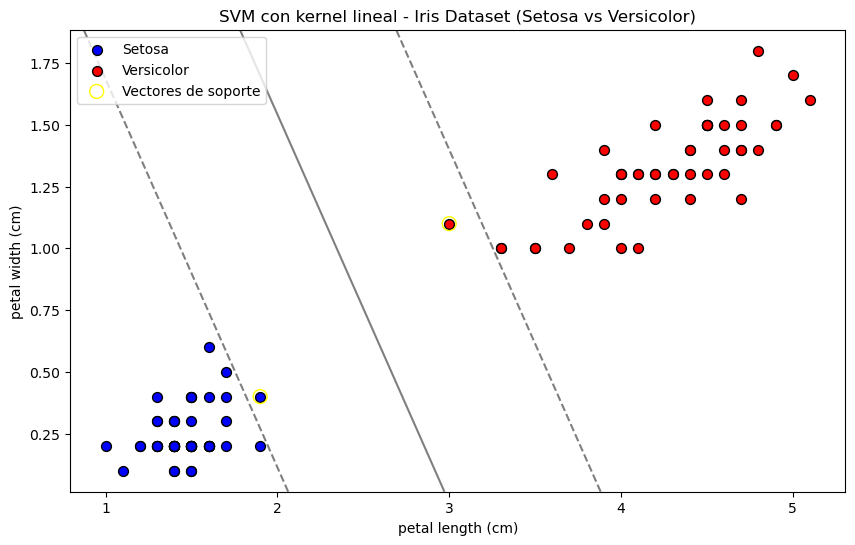

In [87]:
# Importamos las librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

print("Imprimiendo la matriz de correlación entre las características:")
df = pd.DataFrame(X, columns=feature_names)
display(df.corr('pearson'))

X = iris.data[:100, 2:4]
y = iris.target[:100]

df['especie'] = pd.Categorical.from_codes(iris.target, iris.target_names)

modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X, y)


plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.scatter(X[y == 0, 0], X[y == 0, 1],
           c='blue', s=50, edgecolors='k', label='Setosa')
ax.scatter(X[y == 1, 0], X[y == 1, 1],
           c='red', s=50, edgecolors='k', label='Versicolor')

ylim = ax.get_ylim()
xlim = ax.get_xlim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = modelo_svm.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
ax.scatter(modelo_svm.support_vectors_[:, 0], modelo_svm.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='yellow', label='Vectores de soporte')
plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title('SVM con kernel lineal - Iris Dataset (Setosa vs Versicolor)')
plt.legend()
plt.show()